In [1]:
import pandas as pd

In [10]:
data=pd.read_csv(r"C:\Users\acer\OneDrive\Documents\Weather Data.csv")

 # Data Loading

In [26]:
data.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [27]:
data.shape

(8784, 8)

In [28]:
data.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

 # Data cleaning

In [31]:
data.isnull().sum()

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

In [32]:
data.duplicated().sum()

np.int64(0)

In [35]:
data['Date/Time'] = pd.to_datetime(data['Date/Time'])

In [36]:
data['Month'] = data['Date/Time'].dt.month
data['Hour'] = data['Date/Time'].dt.hour

In [39]:
data.rename(columns={'Weather': 'Weather Condition'}, inplace=True)

In [41]:
data['Weather Condition'].unique()

array(['Fog', 'Freezing Drizzle,Fog', 'Mostly Cloudy', 'Cloudy', 'Rain',
       'Rain Showers', 'Mainly Clear', 'Snow Showers', 'Snow', 'Clear',
       'Freezing Rain,Fog', 'Freezing Rain', 'Freezing Drizzle',
       'Rain,Snow', 'Moderate Snow', 'Freezing Drizzle,Snow',
       'Freezing Rain,Snow Grains', 'Snow,Blowing Snow', 'Freezing Fog',
       'Haze', 'Rain,Fog', 'Drizzle,Fog', 'Drizzle',
       'Freezing Drizzle,Haze', 'Freezing Rain,Haze', 'Snow,Haze',
       'Snow,Fog', 'Snow,Ice Pellets', 'Rain,Haze', 'Thunderstorms,Rain',
       'Thunderstorms,Rain Showers', 'Thunderstorms,Heavy Rain Showers',
       'Thunderstorms,Rain Showers,Fog', 'Thunderstorms',
       'Thunderstorms,Rain,Fog',
       'Thunderstorms,Moderate Rain Showers,Fog', 'Rain Showers,Fog',
       'Rain Showers,Snow Showers', 'Snow Pellets', 'Rain,Snow,Fog',
       'Moderate Rain,Fog', 'Freezing Rain,Ice Pellets,Fog',
       'Drizzle,Ice Pellets,Fog', 'Drizzle,Snow', 'Rain,Ice Pellets',
       'Drizzle,Snow,Fog', 

# Analytical Questions

## Which weather conditions occur most frequently?

In [43]:
data['Weather Condition'].value_counts()

Weather Condition
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle      

## What is the average temperature?

In [44]:
data['Temp_C'].mean()

np.float64(8.798144353369764)

## What are the hottest and coldest recorded temperatures?

In [45]:
data['Temp_C'].max() #hottest

33.0

In [46]:
data['Temp_C'].min() #coldest

-23.3

## What percentage of observations have visibility below 10 km?

In [47]:
percentage = (data['Visibility_km'] < 10).mean() * 100

print(percentage)

9.221311475409836


## What percentage of observations have humidity above 80%?

In [49]:
percentage = (data['Rel Hum_%'] > 80).mean() * 100

print(f"{percentage:.2f}% of observations have humidity above 80%.")

26.39% of observations have humidity above 80%.


## Which weather condition has the highest average temperature?

In [50]:
avg_temp = data.groupby('Weather Condition')['Temp_C'].mean()

print(avg_temp.idxmax())
print(avg_temp.max())


Thunderstorms
24.15


## Which weather condition has the lowest average visibility?

In [51]:
avg_visibility = data.groupby('Weather Condition')['Visibility_km'].mean()

print(avg_visibility.sort_values())

Weather Condition
Moderate Snow,Blowing Snow                  0.600000
Freezing Fog                                0.650000
Moderate Snow                               0.750000
Freezing Rain,Haze                          2.400000
Thunderstorms,Heavy Rain Showers            2.400000
Snow Pellets                                2.400000
Freezing Drizzle,Haze                       2.666667
Thunderstorms,Moderate Rain Showers,Fog     3.200000
Drizzle,Ice Pellets,Fog                     4.000000
Snow,Blowing Snow                           4.105263
Snow,Fog                                    4.537838
Snow,Haze                                   4.640000
Freezing Rain,Snow Grains                   4.800000
Thunderstorms,Rain,Fog                      4.800000
Drizzle,Fog                                 5.257500
Freezing Drizzle,Fog                        5.266667
Drizzle,Snow,Fog                            5.513333
Freezing Drizzle,Snow                       5.872727
Rain,Snow,Ice Pellets       

## Which month has the highest average temperature?

In [52]:
data['Date/Time'] = pd.to_datetime(data['Date/Time'])

In [53]:
data['Month'] = data['Date/Time'].dt.month

In [54]:
monthly_temp = data.groupby('Month')['Temp_C'].mean()

print(monthly_temp)

Month
1     -7.371505
2     -4.225000
3      3.121237
4      7.009306
5     16.237769
6     20.134028
7     22.790054
8     22.279301
9     16.484444
10    10.954973
11     0.931389
12    -3.306317
Name: Temp_C, dtype: float64


In [55]:
print(monthly_temp.sort_values(ascending=False))

Month
7     22.790054
8     22.279301
6     20.134028
9     16.484444
5     16.237769
10    10.954973
4      7.009306
3      3.121237
11     0.931389
12    -3.306317
2     -4.225000
1     -7.371505
Name: Temp_C, dtype: float64


In [56]:
print("Month:", monthly_temp.idxmax())
print("Average temperature:", monthly_temp.max())

Month: 7
Average temperature: 22.79005376344086


## What is the average temperature for each hour of the day?

In [57]:
data['Hour'] = data['Date/Time'].dt.hour


In [58]:
hourly_temp = data.groupby('Hour')['Temp_C'].mean()

print(hourly_temp)

Hour
0      7.568579
1      7.090437
2      6.656011
3      6.291803
4      5.969126
5      5.717760
6      6.033060
7      6.572951
8      7.378142
9      8.326230
10     9.277596
11    10.107650
12    10.856557
13    11.393716
14    11.775956
15    11.884153
16    11.765574
17    11.276503
18    10.656284
19    10.022951
20     9.360109
21     8.806557
22     8.369399
23     7.998361
Name: Temp_C, dtype: float64


<Axes: title={'center': 'Average Temperature by Hour'}, xlabel='Hour'>

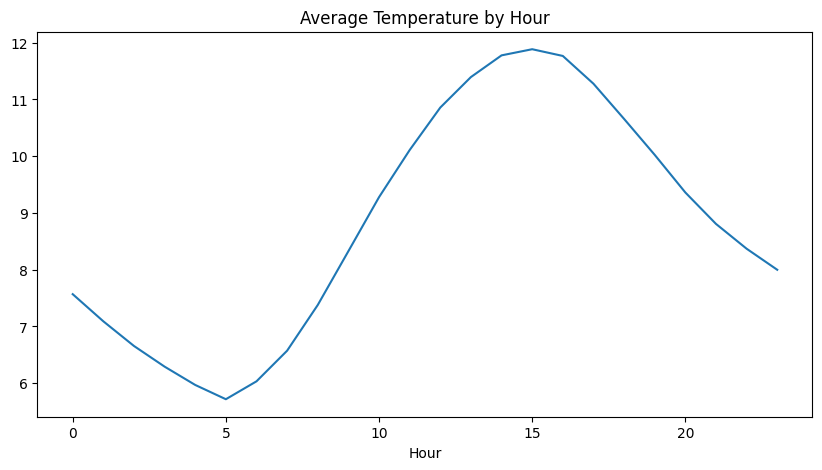

In [61]:
hourly_temp.plot(
    kind='line',
    figsize=(10,5),
    title='Average Temperature by Hour'
)

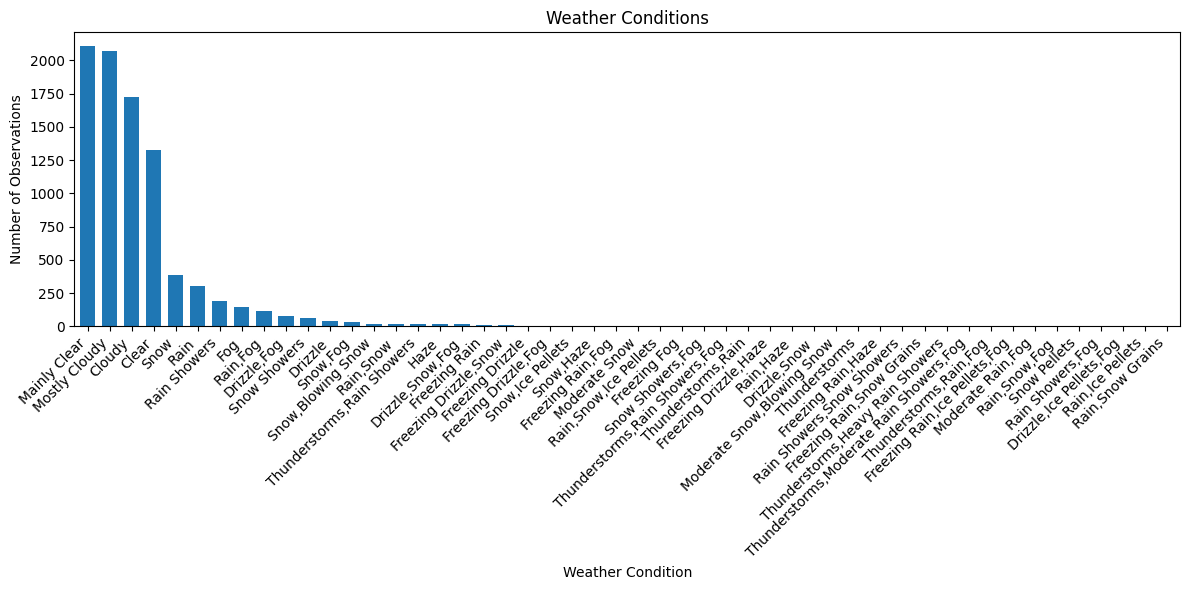

In [71]:
import matplotlib.pyplot as plt

weather_condition_counts = data['Weather Condition'].value_counts()

plt.figure(figsize=(12, 6))

weather_condition_counts.plot(kind='bar', width=0.7)

plt.title('Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Observations')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('weather_conditions.png', bbox_inches='tight')

plt.show()

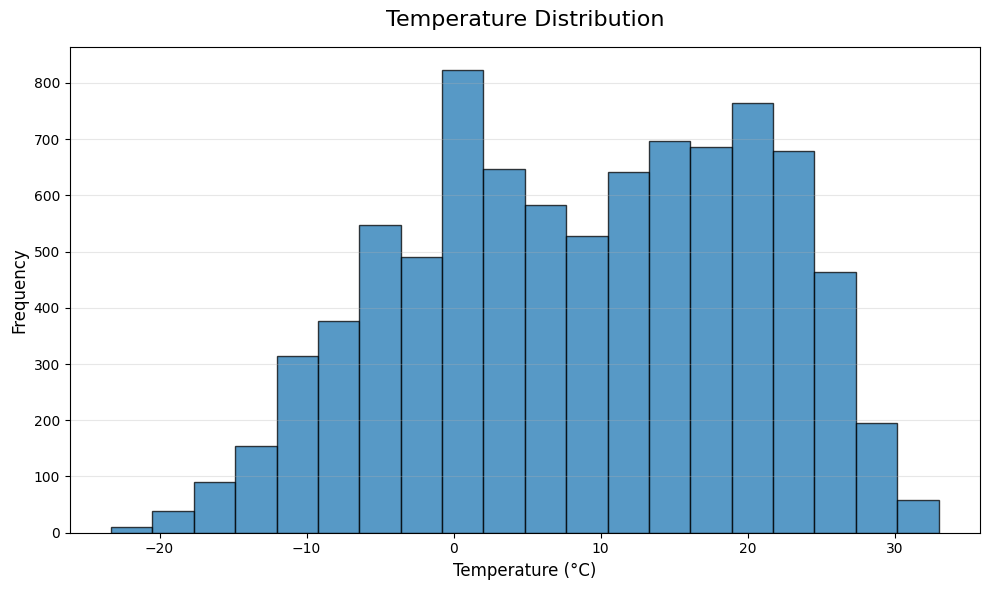

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

data['Temp_C'].plot(
    kind='hist',
    bins=20,
    edgecolor='black',
    alpha=0.75
)

plt.title('Temperature Distribution', fontsize=16, pad=15)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('temperature_distribution.png', bbox_inches='tight', dpi=300)

plt.show()

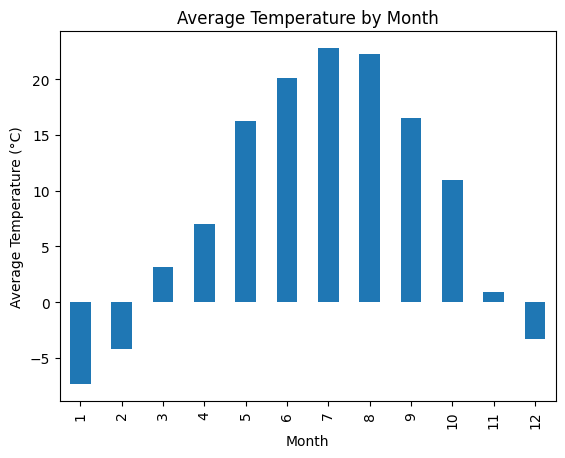

In [74]:
monthly_temp = data.groupby('Month')['Temp_C'].mean()

monthly_temp.plot(kind='bar')

plt.title('Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')

plt.savefig('monthly_temperature.png', bbox_inches='tight')

plt.show()

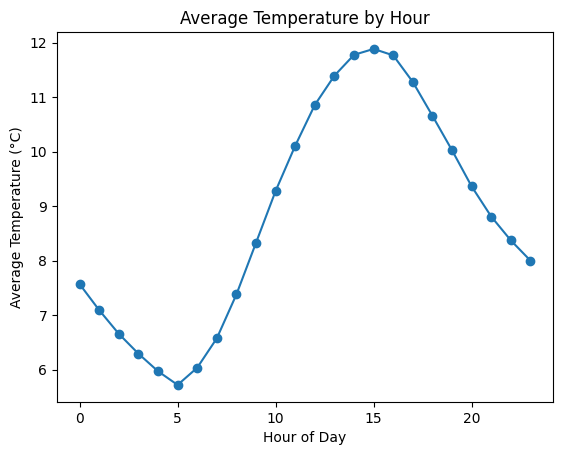

In [75]:
hourly_temp = data.groupby('Hour')['Temp_C'].mean()

hourly_temp.plot(kind='line', marker='o')

plt.title('Average Temperature by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Temperature (°C)')

plt.savefig('hourly_temperature.png', bbox_inches='tight')

plt.show()